# Working with MOS target Parquet files

## Learning goals

The goal of this tutorial is to introduce you to the MOS target Parquet files, which contain information about the targets observed with the SDSS-V Multi-Object Spectrograph (MOS) spectrographs (i.e., APOGEE and BOSS). By the end of this tutorial, you should be able to:

- Understand what the MOS target files are and what information they contain.
- Access the MOS target files using the `sdss-access` package.
- Read the MOS target Parquet files using `polars` and use the streaming engine to efficiently select data.
- Use the MOS target files to explore targeting information for a specific SDSS-V science program.

## What are the MOS target files?

SDSS-V target selection is a complex process that involves cross-matching multiple input catalogues and then applying various sets of selection criteria to identify targets that are suitable for observation with the SDSS-V MOS spectrographs. Each set of selection criteria is referred to as a "carton" and it defines a target class of objects that are of interest for a specific SDSS-V science program (e.g., RM, AQMES, Galactic Genesis, etc.) The input catalogues, results of the cross-match, and carton outputs, are stored in a PostgreSQL database at University of Utah. The contents of the database are also accessible to the public through the Catalog Archive Server (CAS) for each data release. More information about the SDSS-V target selection process can be found [here](https://www.sdss.org/dr20/targeting/).

The MOS target files contain the same information as the target selection database and are named for each one of the tables in the database. For example, the `catalogdb.catalog` table (`mos_catalog` in CAS) contains the `catalogid` identifiers for each unique target for a specific cross-match. This table is released as the [mos_target_catalog](https://data.sdss.org/datamodel/files/MOS_TARGET/V_TARG/mos_target_catalog.html) file product. The list of all MOS target products can be found in a table at the bottom of [this page](https://sdss.org/dr20/targeting/cross-match/).

For each table/MOS target product we provide two types of files: binary FITS tables and [Parquet files](https://parquet.apache.org). We recommend using [Parquet files](#using-parquet-files) as they are smaller, more efficient to read, and they can be processed in such a way that you can handle data that is larger than your computer's memory. This tutorial uses the Parquet files. Check the `mos_target_fits.ipynb` notebook for an example of how to read the FITS files.

## Dependencies

This tutorial makes use of the following Python packages:

- `sdss-access` to access SDSS data.
- `polars` to scan Parquet files and filter results.
- `matplotlib` and `seaborn` for plotting.
- `pyarrow`, recommended for `seaborn` to work with `polars` dataframes, but not strictly necessary.

These packages can be installed using `pip`:

```bash
pip install sdss_access polars matplotlib seaborn pyarrow
```

Although we recommend using `polars` to handle Parquet files, we also show an example of how to read a Parquet file using `pandas`. You can install `pandas` with `pip install pandas`.


## Which files should I use?

These are our recommendations when querying the MOS targeting data:

- If you can, use [CASJobs](https://casjobs.sdss.org/) to query the `mos_` tables. Those tables have indices that will make most queries faster, and you don't need to worry about downloading large files or making sure your computer has enough memory.
- If CASJobs is not an option, use the Parquet files and `polars` to read them. With Parquet files you don't need to worry about chunking, and `polars` will allow you to perform operations on the data without having to load it all in memory.
- Use FITS files only as a last resource if you are using a programming language that doesn't have good support for Parquet files (e.g., IDL) or if you want to use the files with a software that only accepts FITS files.


## Using Parquet files

Let's first explain what we aim to do in this tutorial and what files we'll need. We want to select all the objects targeted in the [Galactic Genesis carton](https://sdss.org/dr20/mwm/programs/gg/) and retrieve their `sdss_ids` (the SDSS unique identifier). Finally, we'll plot the distribution of the targets in Galactic coordinates using Gaia DR3 data.

### Downloading the files

Before we start, we need to make sure we have access to the appropriate MOS target files. Some of these files are fairly large so we recommend that you run this tutorial in a SciServer environment or in a computer with at least 100GB of free disk space. Let's write a function to check the files exist and download them if they don't:


In [1]:
from sdss_access import Access, Path

import os
import os.path


# For DR20, the targeting version is 2.0.0.
V_TARG = "2.0.0"

# If necessary, set the SAS_BASE_PATH environment variable.
# os.environ["SAS_BASE_DIR"] = "/uufs/chpc.utah.edu/common/home/sdss50/"


def get_mos_target_parquet_path(mos_target_product):
    """Get the path to the Parquet file for a given MOS target product, downloading it if it doesn't exist."""

    path = Path(release="DR20")

    # Get the local SAS path to the Parquet file for the specified MOS target product.
    mos_target_path = path.full(mos_target_product, v_targ=V_TARG, ftype="parquet")

    # Check if the file exists locally, and if not, download it.
    if not os.path.exists(mos_target_path):
        access = Access(release="DR20")
        access.remote()
        access.add(mos_target_product, v_targ=V_TARG, ftype="parquet")
        access.set_stream()
        access.commit()

    return mos_target_path

We'll get the paths for a series of files now. We'll explain how to use each one of them as we go.

<div class="alert alert-block alert-warning">
<b>Warning:</b> The next cells will download over 35GB of data to your computer. Consider running this tutorial in a SciServer environment.
</div>


In [2]:
mos_carton_file = get_mos_target_parquet_path("mos_target_carton")
mos_carton_to_target_file = get_mos_target_parquet_path("mos_target_carton_to_target")
mos_target_file = get_mos_target_parquet_path("mos_target_target")
mos_sdss_id_flat_file = get_mos_target_parquet_path("mos_target_sdss_id_flat")

Let's start by opening one of the files and understanding what we get. We'll use the `mos_target_carton` file. In this tutorial we will use the [polars](https://docs.pola.rs) library (see below for a quick example reading a file using `pandas`). One of the main advantages of using `polars` is that we can do "lazy" operations, which allows us to work with files that could not otherwise fit in memory. The lazy API optimised how certain operations are performed and streams data in such a way that we don't overflow the computer memory. The data structure we work with is a dataframe, which is a table-like data structure that allows us to easily manipulate and analyze the data. Let's read the `mos_target_carton` file and see what it looks like:


In [3]:
import polars

mos_carton = polars.scan_parquet(mos_carton_file)
print(mos_carton.sort("carton").head(10).collect())

shape: (10, 7)
┌─────────────────┬───────────┬───────────┬─────────────┬────────────┬────────────┬────────────────┐
│ carton          ┆ carton_pk ┆ mapper_pk ┆ category_pk ┆ version_pk ┆ program    ┆ target_selecti │
│ ---             ┆ ---       ┆ ---       ┆ ---         ┆ ---        ┆ ---        ┆ on_plan        │
│ str             ┆ i32       ┆ i32       ┆ i32         ┆ i32        ┆ str        ┆ ---            │
│                 ┆           ┆           ┆             ┆            ┆            ┆ str            │
╞═════════════════╪═══════════╪═══════════╪═════════════╪════════════╪════════════╪════════════════╡
│ bhm_aqmes_bonus ┆ 291       ┆ 1         ┆ 0           ┆ 49         ┆ bhm_filler ┆ 0.1.0          │
│ -bright         ┆           ┆           ┆             ┆            ┆            ┆                │
│ bhm_aqmes_bonus ┆ 290       ┆ 1         ┆ 0           ┆ 49         ┆ bhm_filler ┆ 0.1.0          │
│ -dark           ┆           ┆           ┆             ┆            ┆      

First, we used `scan_parquet` to load the file. Unlike `read_parquet`, which would read the entire dataframe in memory, `scan_parquet` creates a lazy dataframe that allows us to perform lazy operations. Next we have sorted the dataframe by the `carton` column and used `head(10)` to select the first 10 rows of the sorted dataframe. Finally, we have used `collect()` to execute the lazy operations and return a new dataframe with the results. In general lazy operations like `sort` or `head` don't do anything until `collect()` is called. When this happens the streaming engine decides how to best perform the operations and returns the results without having to load the entire dataframe in memory.

The `carton` table contains a list of all the cartons that have been defined in SDSS-V. The column `carton_pk` is the unique identifier for each carton and the `carton` column contains the name of the carton. Similarly, the `carton_to_target` table contains the mapping between the cartons and the targets (`target`), which are identified by their `catalogid`. The same physical object can have different `catalogids`, corresponding to different cross-matches, but it will only have one `sdss_id`, which is the global for each target in SDSS. The `sdss_id_flat` table contains the mapping between the `catalogid` and the `sdss_id`.

We are going to perform a series of joins from `carton` to `sdss_id_flat`. After that, we will select only the targets in the Galactic Genesis carton and retrieve their `sdss_ids`. Let's start by defining those joins.


In [4]:
mos_carton_to_target = polars.scan_parquet(mos_carton_to_target_file)
mos_target = polars.scan_parquet(mos_target_file)
mos_sdss_id_flat = polars.scan_parquet(mos_sdss_id_flat_file)

# Performing a series of joins from carton to sdss_id_flat.
# Note that nothing is actually happening until we call collect() at the end.
df = (
    mos_carton.join(mos_carton_to_target, left_on="carton_pk", right_on="carton_pk")
    .join(mos_target, left_on="target_pk", right_on="target_pk")
    .join(mos_sdss_id_flat, left_on="catalogid", right_on="catalogid")
)

Now we'll apply a filter to select only the targets in the Galactic Genesis cartons. Throughout SDSS-V several cartons have been defined to match the Galactic Genesis sample, with all starting with the name `mwm_galactic_core`. In `polars` we can match all these cartons with the expression `polars.col.carton.str.starts_with("mwm_galactic_core")`. `polars.col` is a way to refer to a specific column in a dataframe and use it in an expression. `.str` is an accessor to string operations, and `starts_with` is a method to check if a string starts with a specific substring. The same `catalogid` and `sdss_id` can be in multiple targets, so we will also apply a `unique` operation to keep only one entry per target.


In [5]:
# Select targets in the Galactic Genesis cartons.
gal_gen = df.filter(polars.col.carton.str.starts_with("mwm_galactic_core_dist")).unique(subset=["sdss_id"])

# Print a sample of the results. We select only the `sdss_id` and `catalogid` columns.
print(gal_gen.select("sdss_id", "catalogid").head(10).collect())

# Let's see how many targets we have in the Galactic Genesis cartons.
n_gal_gen = gal_gen.select(polars.len()).collect()
print(f"There are {n_gal_gen.item(0, 0):,d} unique targets in the Galactic Genesis cartons.")

shape: (10, 2)
┌───────────┬───────────────────┐
│ sdss_id   ┆ catalogid         │
│ ---       ┆ ---               │
│ i64       ┆ i64               │
╞═══════════╪═══════════════════╡
│ 83979117  ┆ 63050395383845285 │
│ 55068668  ┆ 63050394800432164 │
│ 89978379  ┆ 63050395757740822 │
│ 116823931 ┆ 63050396583568709 │
│ 88149822  ┆ 63050395689978034 │
│ 104332279 ┆ 63050396181990470 │
│ 82678150  ┆ 63050395302978464 │
│ 112889322 ┆ 63050396508683646 │
│ 83144003  ┆ 63050395326385942 │
│ 66840823  ┆ 63050395002386204 │
└───────────┴───────────────────┘
There are 6,003,617 unique targets in the Galactic Genesis cartons.


If we want to save the results to a Parquet file we can do it with the `sink_parquet` method. For example

```python
gal_gen.select("sdss_id", "catalogid").sink_parquet("galactic_genesis_targets.parquet")
```

Note that `collect()` is not needed in this case because `sink_parquet` will execute the lazy operations.


We are now going to to get the Galactic coordinates for these targets in the Gaia DR3 table. To do that we need two additional tables: `mos_target_gaia_dr3_source` and `mos_target_catalog_to_gaia_dr3_source`. The first one is the Gaia DR3 source catalogue while the second is a relational table that maps the `catalogid` to the Gaia DR3 `source_id`. **The combined size of these two tables is about 23GB**.


In [6]:
mos_catalog_to_gaia_dr3_file = get_mos_target_parquet_path("mos_target_catalog_to_gaia_dr3_source")
mos_gaia_dr3_file = get_mos_target_parquet_path("mos_target_gaia_dr3_source")

In [7]:
# Peek the contents of the catalog_to_gaia_dr3_source table.
mos_catalog_to_gaia_dr3 = polars.scan_parquet(mos_catalog_to_gaia_dr3_file)
print(mos_catalog_to_gaia_dr3.head(10).collect())

shape: (10, 5)
┌───────────────────┬────────────────────┬────────────┬──────────┬──────┐
│ catalogid         ┆ target_id          ┆ version_id ┆ distance ┆ best │
│ ---               ┆ ---                ┆ ---        ┆ ---      ┆ ---  │
│ i64               ┆ i64                ┆ i16        ┆ f64      ┆ bool │
╞═══════════════════╪════════════════════╪════════════╪══════════╪══════╡
│ 63050394783186977 ┆ 421450778387497216 ┆ 31         ┆ null     ┆ true │
│ 63050394783186991 ┆ 421450817049644928 ┆ 31         ┆ null     ┆ true │
│ 63050394783187015 ┆ 421450885769111296 ┆ 31         ┆ null     ┆ true │
│ 63050394783187034 ┆ 421450954488575360 ┆ 31         ┆ null     ┆ true │
│ 63050394783187044 ┆ 421450988848311424 ┆ 31         ┆ null     ┆ true │
│ 63050394783187068 ┆ 421451091927539072 ┆ 31         ┆ null     ┆ true │
│ 63050394783187081 ┆ 421451126287566336 ┆ 31         ┆ null     ┆ true │
│ 63050394783187138 ┆ 421451298078818304 ┆ 31         ┆ null     ┆ true │
│ 63050394783187176 ┆ 4

The `target_id` column matches `source_id` in the Gaia DR3 table. `version_id` is the version of the cross-match. Given that `catalogids` are unique across cross-matches, we can ignore this column for our case. `best` indicates the best match for a target in Gaia DR3 when multiple matches are possible.

We will join our `gal_gen` dataframe with the `catalog_to_gaia_dr3` dataframe to get the `source_id` for each target, and then we'll join the resulting dataframe with the `gaia_dr3` dataframe to get the Galactic coordinates.


In [8]:
mos_gaia_dr3 = polars.scan_parquet(mos_gaia_dr3_file)

# Join the gal_gen to Gaia DR3 and select the relevant columns, including
# Galactic coordinates l and b. We materialise the results with collect().
# One should only do that if the resulting table is expected to fit in memory.
gaia_gg_data = (
    gal_gen.join(mos_catalog_to_gaia_dr3, left_on="catalogid", right_on="catalogid")
    .join(mos_gaia_dr3, left_on="target_id", right_on="source_id")
    .filter(polars.col.best)
    .select("sdss_id", "catalogid", "ra", "dec", "l", "b")
    .collect()
)

print(gaia_gg_data)

shape: (6_003_617, 6)
┌───────────┬───────────────────┬────────────┬───────────┬────────────┬────────────┐
│ sdss_id   ┆ catalogid         ┆ ra         ┆ dec       ┆ l          ┆ b          │
│ ---       ┆ ---               ┆ ---        ┆ ---       ┆ ---        ┆ ---        │
│ i64       ┆ i64               ┆ f64        ┆ f64       ┆ f64        ┆ f64        │
╞═══════════╪═══════════════════╪════════════╪═══════════╪════════════╪════════════╡
│ 114816737 ┆ 63050396551223108 ┆ 45.490906  ┆ 0.741372  ┆ 176.671934 ┆ -48.034428 │
│ 114816743 ┆ 63050396551223147 ┆ 45.305053  ┆ 0.736093  ┆ 176.483565 ┆ -48.171322 │
│ 114816884 ┆ 63050396551223591 ┆ 44.46438   ┆ 0.581058  ┆ 175.759885 ┆ -48.879117 │
│ 114817226 ┆ 63050396551224821 ┆ 45.804445  ┆ 0.905555  ┆ 176.821198 ┆ -47.694995 │
│ 114817225 ┆ 63050396551224821 ┆ 45.804445  ┆ 0.905555  ┆ 176.821198 ┆ -47.694995 │
│ …         ┆ …                 ┆ …          ┆ …         ┆ …          ┆ …          │
│ 114816034 ┆ 63050396551217835 ┆ 314.81209

Let's plot these results.


Text(0, 0.5, 'Galactic Latitude (degrees)')

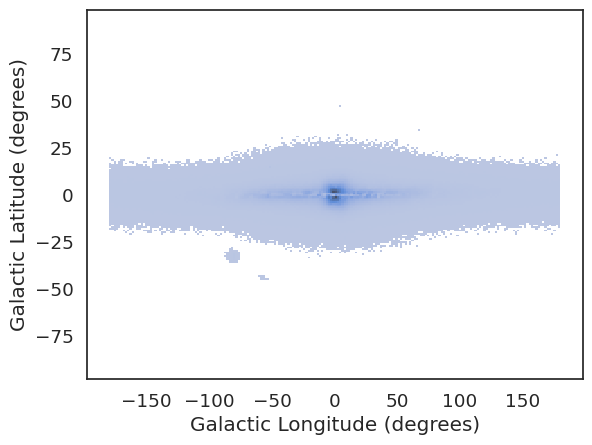

In [9]:
import seaborn

%matplotlib inline

# We add a new column with the Galactic longitude in the range [-180, 180]
# instead of [0, 360] to make the plot easier to read.
# We use the `when` expression in `polars` to apply a condition and create a
# new column based on that condition.
gaia_gg_data = gaia_gg_data.with_columns(
    ll=polars.when(polars.col.l > 180).then(polars.col.l - 360).otherwise(polars.col.l)
)

# Set the theme for the plot.
seaborn.set_theme(style="white", font_scale=1.2)

# Plot the distribution of targets in Galactic coordinates.
# We use a 2D histogram with 200 bins in each direction
# and a threshold of 0.025% to only show bins with a significant number of targets.
ax = seaborn.histplot(gaia_gg_data, x="ll", y="b", bins=200, pthresh=0.025)

ax.set_xlabel("Galactic Longitude (degrees)")
ax.set_ylabel("Galactic Latitude (degrees)")

You can see that Galacic Genesis, as expected, mainly targets stars in the Galactic plane and the Magellanic Clouds.


### Using `pandas` to read Parquet files

It is possible to use `pandas` to read Parquet files. For example:


In [10]:
import pandas

df = pandas.read_parquet(mos_carton_file)
df.sample(10)

,carton,carton_pk,mapper_pk,category_pk,version_pk,program,target_selection_plan
502,mwm_halo_local_low_apogee_triple,1761,0.0,0,206,mwm_halo,1.2.7
226,openfibertargets_nov2020_33,1022,NaN,0,95,open_fiber,0.5.3
296,mwm_bin_gaia_astb_boss,1401,0.0,0,152,mwm_bin,1.0.19
301,mwm_yso_cmz_apogee_single,1468,0.0,0,164,mwm_yso,1.0.33
108,mwm_erosita_stars,770,0.0,0,93,mwm_erosita,0.5.2
93,ops_std_boss_lsdr8,727,NaN,2,83,ops_std,0.5.0
290,ops_std_boss_tic,1376,NaN,2,149,ops_std,1.0.16
490,bhm_spiders_agn_tda_d3,1728,1.0,0,203,bhm_spiders,1.2.4
31,mwm_snc_100pc,126,0.0,0,49,mwm_snc,0.1.0
355,mwm_ob_core_boss,1561,0.0,0,176,mwm_ob,1.0.39


Once open, you can treat it as any other `pandas` dataframe.


In [11]:
df.loc[df.carton == "mwm_galactic_core_dist_apogee"]

,carton,carton_pk,mapper_pk,category_pk,version_pk,program,target_selection_plan
413,mwm_galactic_core_dist_apogee,1628,0.0,0,181,mwm_galactic,1.0.44


However, note that when we run `read_parquet` the entire file was read into memory. [Here](https://pandas.pydata.org/docs/user_guide/scale.html) are a few tips if you need to handle files larger than your computer's memory with `pandas`.


### About this notebook

This notebook was created to introduce the `mos_target` parquet files and to demonstrate usage of the files without running out of system memory.

**Authors**: José Sánchez-Gallego, Pramod Gupta

**Last Update**: 2026 April 21

If you use `astropy`  for published research, please cite the
authors. Follow this link for more information about citing `astropy`:

* [Citing `astropy`](https://www.astropy.org/acknowledging.html)

And of course please [cite](https://sdss.org/collaboration/citing-sdss/) SDSS when you use our data.